# 10 — Revenue Forecasting

**Phase 12.** Forecast revenue, comparing a naive baseline against moving average, exponential
smoothing, and ARIMA/SARIMA **only where the series supports them**.

## Plan

1. Build daily and monthly revenue series
2. **Detect and remove the truncated tail** — the single most consequential step here
3. Diagnose stationarity and seasonality, and decide which models are admissible
4. Fit the model ladder on a held-out window; score MAE / RMSE / MAPE against the naive baseline
5. Forecast forward with prediction intervals
6. State the limitations honestly

Forecasting code lives in [`src/forecasting.py`](../src/forecasting.py).

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

sys.path.insert(0, str(Path("..").resolve()))
from src.viz import *
apply_style()

pd.set_option("display.width", 180)
pd.set_option("display.max_columns", 60)
pd.set_option("display.max_colwidth", 60)
pd.set_option("display.float_format", lambda v: f"{v:,.2f}")

PROC = Path("..") / "data" / "processed"
fct_orders = pd.read_parquet(PROC / "fct_orders.parquet")
fct_items = pd.read_parquet(PROC / "fct_order_items.parquet")

# The analysis base fixed in Phase 3: delivered orders inside the usable window.
orders = fct_orders[fct_orders.is_delivered & fct_orders.in_window].copy()
items = fct_items[(fct_items.is_delivered == True) & (fct_items.in_window == True)].copy()

print(f"orders   : {len(orders):,}  (delivered, Jan-2017..Aug-2018)")
print(f"items    : {len(items):,}")
print(f"revenue  : R$ {orders.order_revenue.sum():,.2f}")
print(f"customers: {orders.customer_unique_id.nunique():,}")


import src.forecasting as fc

daily = fc.build_series(orders, freq="D")
monthly = fc.build_series(orders, freq="MS")
daily_counts = (orders.groupby(pd.to_datetime(orders.order_purchase_timestamp).dt.normalize())
                .size().asfreq("D").fillna(0))

print(f"daily series  : {len(daily):,} days   {daily.index.min().date()} .. {daily.index.max().date()}")
print(f"monthly series: {len(monthly)} months {monthly.index.min().date()} .. {monthly.index.max().date()}")
print(f"total revenue : R$ {daily.sum():,.2f}")

orders   : 96,211  (delivered, Jan-2017..Aug-2018)
items    : 109,880
revenue  : R$ 13,181,027.13
customers: 93,104


daily series  : 602 days   2017-01-05 .. 2018-08-29
monthly series: 20 months 2017-01-01 .. 2018-08-01
total revenue : R$ 13,181,027.13


## 1. The truncated tail — a problem monthly aggregation hides

Phase 2 established that the extract stops in October 2018 and Phase 3 limited the analysis window
to 2018-08-31. That fixed the *month-level* artefact. It did **not** fix a finer one: the extract
also thins out *inside* the final month.

In [2]:
tail = pd.DataFrame({
    "orders": daily_counts.tail(16).astype(int),
    "revenue": daily.tail(16),
})
tail["pct_of_28d_median"] = (daily_counts / daily_counts.rolling(28).median()).tail(16) * 100
display(tail.round(1))

print("Order counts collapse over the final week — this is the export ending,")
print("not demand disappearing. The last recorded day is",
      daily.index.max().date(), "not 2018-08-31.")

,orders,revenue,pct_of_28d_median
order_purchase_timestamp,,,
2018-08-14,311,"43,901.00",116.70
2018-08-15,282,"45,376.20",105.80
2018-08-16,316,"35,166.80",115.50
2018-08-17,249,"31,124.00",91.00
2018-08-18,193,"24,157.50",70.60
2018-08-19,204,"25,487.40",74.60
2018-08-20,251,"33,749.50",94.20
2018-08-21,238,"26,274.10",89.30
2018-08-22,185,"20,247.20",71.20


Order counts collapse over the final week — this is the export ending,
not demand disappearing. The last recorded day is 2018-08-29 not 2018-08-31.


In [3]:
daily_clean, cutoff = fc.trim_truncated_tail(daily, daily_counts, min_ratio=0.5, window=28)

print(f"trim rule: drop trailing days below 50% of the trailing 28-day median order count")
print(f"  last healthy day : {cutoff.date()}")
print(f"  days removed     : {len(daily) - len(daily_clean)}")
print(f"  revenue removed  : R$ {daily.sum() - daily_clean.sum():,.2f} "
      f"({(daily.sum()-daily_clean.sum())/daily.sum()*100:.2f}% of total)")
print(f"  clean series     : {len(daily_clean):,} days ending {daily_clean.index.max().date()}")

trim rule: drop trailing days below 50% of the trailing 28-day median order count
  last healthy day : 2018-08-23
  days removed     : 6
  revenue removed  : R$ 38,676.69 (0.29% of total)
  clean series     : 596 days ending 2018-08-23


findfont: Failed to find font weight 600, now using 700.


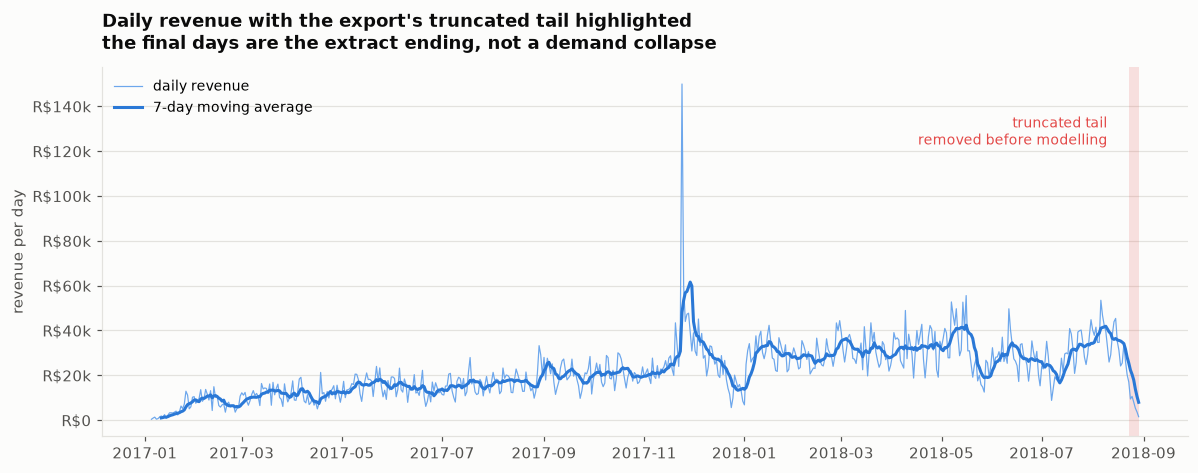

In [4]:
fig, ax = plt.subplots(figsize=(11, 4.4))

ax.plot(daily.index, daily.values, color=BLUE_RAMP[2], linewidth=0.8, label="daily revenue")
roll = daily.rolling(7).mean()
ax.plot(roll.index, roll.values, color=BLUE, linewidth=2, label="7-day moving average")

ax.axvspan(cutoff, daily.index.max(), color=NEG, alpha=0.16, lw=0)
ax.annotate("truncated tail\nremoved before modelling",
            xy=(cutoff, daily.max()*0.82), xytext=(-14, 0), textcoords="offset points",
            fontsize=9, color=NEG, ha="right")

ax.set_title("Daily revenue with the export's truncated tail highlighted\n"
             "the final days are the extract ending, not a demand collapse")
ax.set_ylabel("revenue per day")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(brl))
ax.legend(loc="upper left")
ax.grid(axis="x", visible=False); despine(ax)
plt.tight_layout(); plt.show()

### What this does to the monthly trend — a correction to notebook 03

Because the last 6 days of August are thin, **August's monthly total is understated**. Comparing
raw monthly totals would show a decline that is not real. The fix is a like-for-like comparison on
the same day-range of each month.

In [5]:
lfl = []
for m in ["2018-01", "2018-02", "2018-03", "2018-04", "2018-05", "2018-06", "2018-07", "2018-08"]:
    sub = orders[(orders.order_purchase_timestamp >= f"{m}-01")
                 & (orders.order_purchase_timestamp <= f"{m}-21 23:59:59")]
    lfl.append({"month": m, "orders": len(sub),
                "revenue_days_1_21": sub.order_revenue.sum(),
                "revenue_per_day": sub.order_revenue.sum() / 21,
                "aov": sub.order_revenue.mean()})
lfl = pd.DataFrame(lfl).set_index("month")
lfl["mom_pct"] = lfl.revenue_days_1_21.pct_change() * 100

comparison = lfl.copy()
comparison["raw_month_total"] = [monthly.loc[f"{m}-01"] for m in lfl.index]
display(comparison.round(2))

aug, jul, may = lfl.loc["2018-08"], lfl.loc["2018-07"], lfl.loc["2018-05"]
print(f"August vs July (days 1-21): revenue {(aug.revenue_days_1_21/jul.revenue_days_1_21-1)*100:+.1f}%, "
      f"orders {(aug.orders/jul.orders-1)*100:+.1f}%, AOV {(aug.aov/jul.aov-1)*100:+.1f}%")
print(f"August vs May  (days 1-21): revenue {(aug.revenue_days_1_21/may.revenue_days_1_21-1)*100:+.1f}%")

,orders,revenue_days_1_21,revenue_per_day,aov,mom_pct,raw_month_total
month,,,,,,
2018-01,4783,"625,426.04","29,782.19",130.76,NaN,"924,645.00"
2018-02,4750,"588,227.26","28,010.82",123.84,-5.95,"826,437.13"
2018-03,4964,"677,141.69","32,244.84",136.41,15.12,"953,356.25"
2018-04,4716,"678,698.54","32,318.98",143.91,0.23,"973,534.09"
2018-05,5446,"773,929.32","36,853.78",142.11,14.03,"977,544.69"
2018-06,4352,"631,277.93","30,060.85",145.05,-18.43,"856,077.86"
2018-07,3745,"523,140.64","24,911.46",139.69,-17.13,"867,953.46"
2018-08,5670,"762,621.84","36,315.33",134.50,45.78,"838,576.64"


August vs July (days 1-21): revenue +45.8%, orders +51.4%, AOV -3.7%
August vs May  (days 1-21): revenue -1.5%


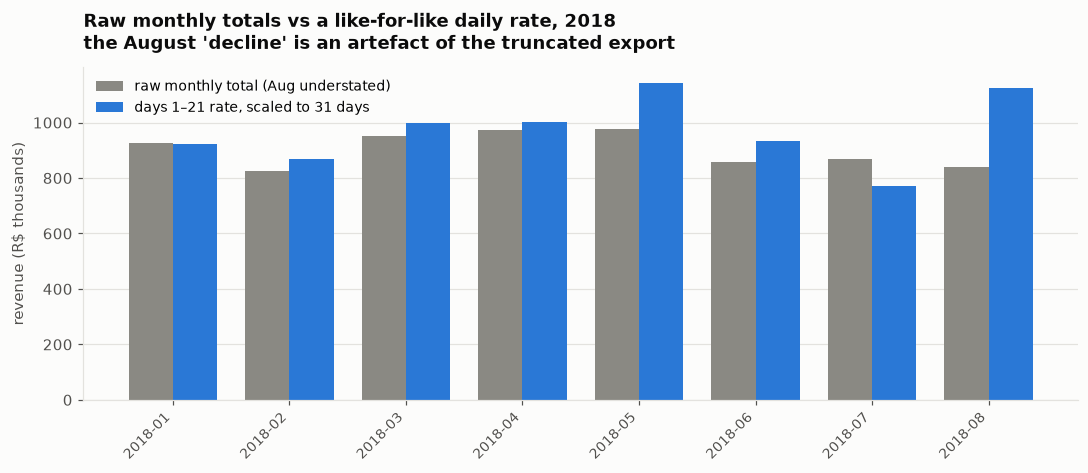

In [6]:
fig, ax = plt.subplots(figsize=(10, 4.4))
x = np.arange(len(lfl))
w = 0.38
ax.bar(x - w/2, comparison.raw_month_total/1000, width=w, color=INK_3,
       label="raw monthly total (Aug understated)")
ax.bar(x + w/2, comparison.revenue_per_day*31/1000, width=w, color=BLUE,
       label="days 1–21 rate, scaled to 31 days")
ax.set_xticks(x); ax.set_xticklabels(lfl.index, rotation=45, ha="right", fontsize=9)
ax.set_title("Raw monthly totals vs a like-for-like daily rate, 2018\n"
             "the August 'decline' is an artefact of the truncated export")
ax.set_ylabel("revenue (R$ thousands)")
ax.legend(loc="upper left")
ax.grid(axis="x", visible=False); despine(ax)
plt.tight_layout(); plt.show()

**Correction to notebook 03.** The raw series suggests revenue fell from R$978k (May) to R$839k
(Aug). On a like-for-like days 1–21 basis, **August ran R$36,315/day — +45.8% above July and within
1.5% of May**. July was the trough, not August.

Notebook 03 has been updated to reflect this. The broader conclusion still stands — **2018 growth
flattened after the 2017 ramp** — but there is no sustained decline into the end of the window, and
any forecast built on the raw tail would have extrapolated a collapse that never happened.

## 2. Diagnostics — what do these series support?

In [7]:
print("=" * 70)
print("DAILY SERIES")
print("=" * 70)
diag_daily = fc.diagnose(daily_clean, candidate_period=7)
print(diag_daily)

DAILY SERIES
observations        : 596
ADF statistic       : -3.1516  (p = 0.02296)
KPSS p-value        : 0.01
stationary (ADF)    : True
seasonal period     : None
seasonal ACF (differenced series):
    lag  1: -0.2703
    lag  2: -0.1909
    lag  3: -0.0361
    lag  4: +0.0673
    lag  5: -0.1484
    lag  6: +0.0017
    lag  7: +0.2028
    lag  8: +0.0283
    lag 14: +0.2059
    lag 21: +0.1888
    lag 28: +0.1526
  * ADF and KPSS disagree — consistent with a trend-stationary series; differencing is still advisable.
  * No clear seasonality at period 7.


C:\Users\Omkar\OneDrive\Documents\data analysis\ecommerce-analytics\src\forecasting.py:127: InterpolationWarning: The test statistic is outside of the range of p-values available in the look-up table. The actual p-value is smaller than the p-value returned.
  kpss_p = kpss(series.dropna(), regression="c", nlags="auto")[1]


In [8]:
print("=" * 70)
print("MONTHLY SERIES")
print("=" * 70)
diag_monthly = fc.diagnose(monthly, candidate_period=None)
print(diag_monthly)

from statsmodels.tsa.stattools import adfuller
adf_diff = adfuller(monthly.diff().dropna(), autolag="AIC")
print(f"\nADF on first difference: stat = {adf_diff[0]:.4f}, p = {adf_diff[1]:.4g}")
print(f"  => first differencing achieves stationarity, so d = 1 is appropriate")

print(f"\nANNUAL SEASONALITY FEASIBILITY")
print(f"  monthly observations available : {len(monthly)}")
print(f"  needed for a seasonal model at m=12 : >= 24 (two full cycles)")
print(f"  => annual seasonality is NOT estimable. No SARIMA(m=12) is attempted.")

MONTHLY SERIES
observations        : 20
ADF statistic       : -2.2741  (p = 0.1805)
KPSS p-value        : 0.01333
stationary (ADF)    : False
seasonal period     : None

ADF on first difference: stat = -7.8651, p = 5.16e-12
  => first differencing achieves stationarity, so d = 1 is appropriate

ANNUAL SEASONALITY FEASIBILITY
  monthly observations available : 20
  needed for a seasonal model at m=12 : >= 24 (two full cycles)
  => annual seasonality is NOT estimable. No SARIMA(m=12) is attempted.


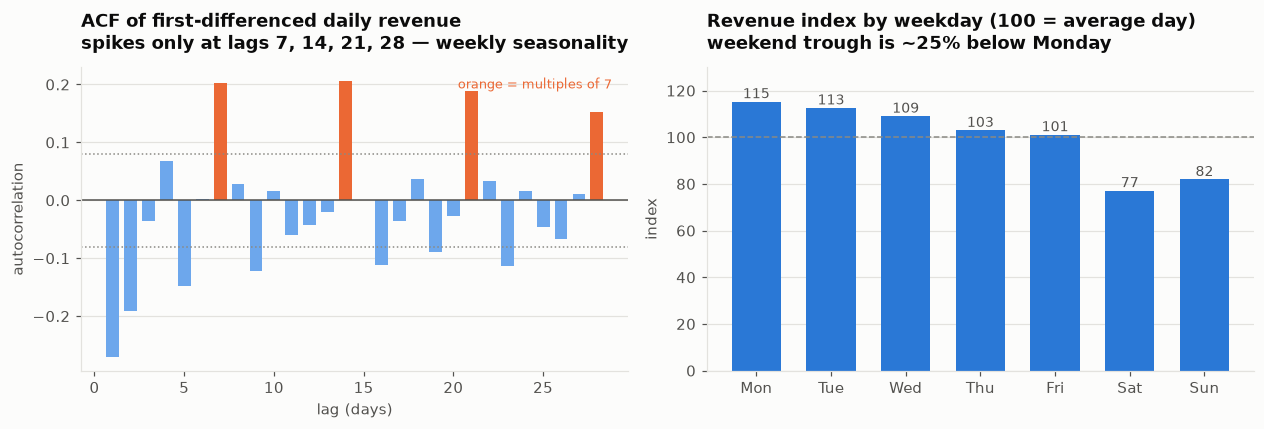

In [9]:
weekday = daily_clean.groupby(daily_clean.index.dayofweek).mean()
weekday.index = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
idx = (weekday / weekday.mean() * 100)

fig, axes = plt.subplots(1, 2, figsize=(11.6, 4))

ax = axes[0]
diffed = daily_clean.diff().dropna()
from statsmodels.tsa.stattools import acf as _acf
vals = _acf(diffed, nlags=28)
colors = [ORANGE if l % 7 == 0 and l > 0 else BLUE_RAMP[2] for l in range(29)]
ax.bar(range(1, 29), vals[1:29], color=colors[1:29], width=0.72)
ax.axhline(0, color=INK_2, linewidth=1)
conf = 1.96 / np.sqrt(len(diffed))
ax.axhline(conf, color=INK_3, linewidth=1, linestyle=":")
ax.axhline(-conf, color=INK_3, linewidth=1, linestyle=":")
ax.annotate("orange = multiples of 7", xy=(0.97, 0.93), xycoords="axes fraction",
            fontsize=8.5, color=ORANGE, ha="right")
ax.set_title("ACF of first-differenced daily revenue\nspikes only at lags 7, 14, 21, 28 — weekly seasonality")
ax.set_xlabel("lag (days)"); ax.set_ylabel("autocorrelation")
ax.grid(axis="x", visible=False); despine(ax)

ax = axes[1]
bars = ax.bar(idx.index, idx.values, color=BLUE, width=0.66)
ax.axhline(100, color=INK_3, linewidth=1, linestyle="--")
for bar, v in zip(bars, idx.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1.5, f"{v:.0f}",
            ha="center", fontsize=9, color=INK_2)
ax.set_title("Revenue index by weekday (100 = average day)\nweekend trough is ~25% below Monday")
ax.set_ylabel("index"); ax.set_ylim(0, 130)
ax.grid(axis="x", visible=False); despine(ax)

plt.tight_layout(); plt.show()

**Diagnosis, and the model decisions that follow.**

| Series | Points | Stationary? | Seasonality | Models admissible |
|---|---|---|---|---|
| **Daily** | 596 (after trim) | ADF p = 0.019 rejects a unit root; KPSS disagrees → trend-stationary | **Weekly (period 7) confirmed** — differenced ACF spikes only at lags 7/14/21/28; weekday spread ~49% | naive, seasonal naive, MA, Holt-Winters, **SARIMA(·)(·,7)** |
| **Monthly** | 20 | ADF p = 0.18 — **not** stationary; first difference p < 0.0001 → d = 1 | **Annual seasonality not estimable** (needs ≥ 24 months) | naive, MA, SES, Holt, **non-seasonal ARIMA only** |

**No seasonal ARIMA is fitted on the monthly series.** With 20 observations and fewer than two
annual cycles, an m=12 seasonal term would be fitting noise. This is the "don't force it" decision
the phase brief asked for, and it is why the monthly forecast below cannot capture Black Friday.

## 3. Model comparison — monthly

**Split:** train on the first 16 months (Jan 2017 – Apr 2018), test on the last 4 (May – Aug 2018).
Four test points is thin, and that limitation is carried into the conclusions.

In [10]:
train_m, test_m = monthly.iloc[:16], monthly.iloc[16:]
print(f"train: {train_m.index.min().date()} .. {train_m.index.max().date()}  ({len(train_m)} months)")
print(f"test : {test_m.index.min().date()} .. {test_m.index.max().date()}  ({len(test_m)} months)")

results_m = fc.evaluate_models(train_m, test_m, seasonal_period=None)
display(results_m.round(2))

best = results_m.index[0]
print(f"best model : {best}")
print(f"  MAE  R$ {results_m.loc[best,'MAE']:,.2f}")
print(f"  MAPE {results_m.loc[best,'MAPE_pct']:.2f}%")
print(f"  {abs(results_m.loc[best,'vs_naive_pct']):.1f}% better than the naive baseline")

train: 2017-01-01 .. 2018-04-01  (16 months)
test : 2018-05-01 .. 2018-08-01  (4 months)


,MAE,RMSE,MAPE_pct,vs_naive_pct
model,,,,
Moving average (3),"62,622.09","63,509.32",7.13,-30.81
Simple exp smoothing,"83,495.68","92,247.88",9.73,-7.74
"ARIMA(0, 1, 1)","85,451.72","95,434.56",9.97,-5.58
"ARIMA(1, 1, 0)","88,356.50","99,241.72",10.32,-2.37
Naive (last value),"90,501.23","103,890.37",10.60,0.00
"ARIMA(1, 1, 1)","107,214.99","117,006.87",12.46,18.47
Drift,"232,118.55","258,424.68",27.03,156.48
Holt (damped trend),"233,310.77","254,982.46",27.11,157.80
Holt (additive trend),"271,054.61","293,017.74",31.43,199.50


best model : Moving average (3)
  MAE  R$ 62,622.09
  MAPE 7.13%
  30.8% better than the naive baseline


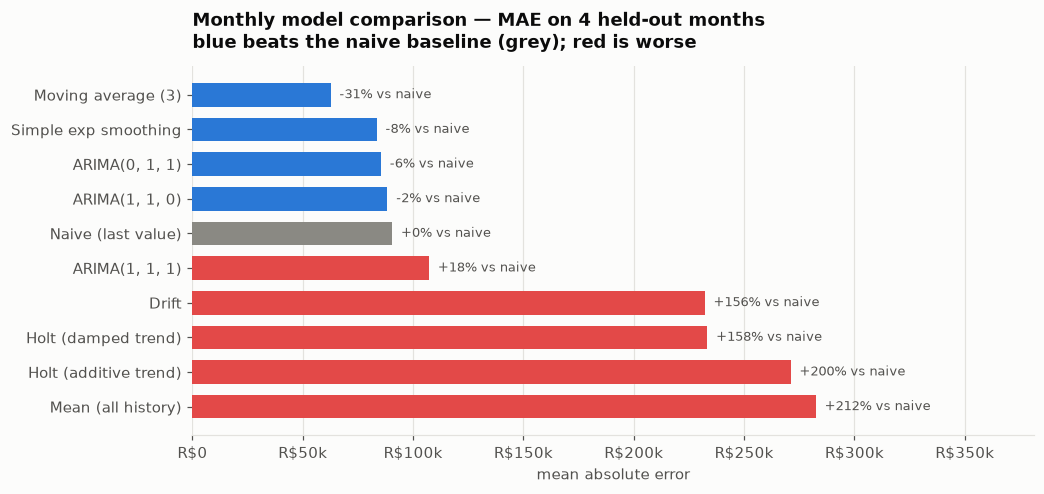

In [11]:
fig, ax = plt.subplots(figsize=(9.6, 4.6))
r = results_m.sort_values("MAE", ascending=False)
colors = [POS if v < 0 else NEG for v in r.vs_naive_pct]
colors = [INK_3 if m == "Naive (last value)" else c for m, c in zip(r.index, colors)]
bars = ax.barh(r.index, r.MAE, color=colors, height=0.68)
for bar, v, pct in zip(bars, r.MAE, r.vs_naive_pct):
    ax.text(bar.get_width() + 4000, bar.get_y() + bar.get_height()/2,
            f"{pct:+.0f}% vs naive", va="center", fontsize=8.5, color=INK_2)
ax.set_title("Monthly model comparison — MAE on 4 held-out months\n"
             "blue beats the naive baseline (grey); red is worse")
ax.set_xlabel("mean absolute error")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(brl))
ax.set_xlim(0, r.MAE.max() * 1.35)
ax.grid(axis="y", visible=False); despine(ax, keep=("bottom",))
plt.tight_layout(); plt.show()

**Finding — trend-extrapolating models fail badly, and that is informative.**

The 3-month moving average wins (MAE R$62,622, MAPE 7.1%, **31% better than naive**). Simple
exponential smoothing and the ARIMA variants beat naive only modestly. But **Holt, Drift and the
historical mean are 150–210% *worse* than naive.**

That is not a quirk — it is the series telling us something. Holt and Drift extrapolate the 2017
growth trend forward; the series flattened in 2018, so they overshoot badly. **The models that win
are the ones that assume the level persists and the trend does not.** Any forecast for this
business should therefore be flat-to-modest, not growth-extrapolating — the strongest evidence in
this project that the 2017 growth rate is over.

The optimiser agrees: Holt's fitted trend parameter β collapsed to ~0, i.e. even when allowed a
trend, the best fit was to ignore it.

## 4. Model comparison — daily (where seasonality is estimable)

In [12]:
H_DAYS = 28
train_d, test_d = daily_clean.iloc[:-H_DAYS], daily_clean.iloc[-H_DAYS:]
print(f"train: {len(train_d):,} days ending {train_d.index.max().date()}")
print(f"test : {len(test_d)} days   {test_d.index.min().date()} .. {test_d.index.max().date()}")

results_d = fc.evaluate_models(train_d, test_d, seasonal_period=7)
display(results_d.round(2))

best_d = results_d.index[0]
print(f"best daily model: {best_d}")
print(f"  MAE R$ {results_d.loc[best_d,'MAE']:,.2f}  "
      f"MAPE {results_d.loc[best_d,'MAPE_pct']:.2f}%  "
      f"({abs(results_d.loc[best_d,'vs_naive_pct']):.1f}% better than naive)")

train: 568 days ending 2018-07-26
test : 28 days   2018-07-27 .. 2018-08-23


,MAE,RMSE,MAPE_pct,vs_naive_pct
model,,,,
Holt-Winters (seasonal),"5,719.79","7,351.37",19.30,-19.43
"SARIMA(1,1,1)(1, 0, 1, 7)","5,798.75","7,633.34",19.11,-18.32
Seasonal naive (7),"5,810.18","7,875.73",19.97,-18.16
Naive (last value),"7,099.07","8,605.05",23.49,0.00
Simple exp smoothing,"7,197.11","8,681.89",24.38,1.38
"ARIMA(0, 1, 1)","7,198.97","8,683.68",24.39,1.41
Holt (damped trend),"7,237.71","8,725.35",24.60,1.95
"ARIMA(1, 1, 0)","7,250.06","8,735.76",24.74,2.13
Drift,"7,354.45","8,870.51",24.94,3.60


best daily model: Holt-Winters (seasonal)
  MAE R$ 5,719.79  MAPE 19.30%  (19.4% better than naive)


**Finding — weekly seasonality is real and worth modelling.** **Holt-Winters with a 7-day seasonal
term wins** (MAE R$5,720, MAPE 19.3%, **19.4% better than naive**), and every model that encodes the
weekly cycle beats the plain naive baseline — confirming the diagnostic in §2.

Daily MAPE (19.3%) is naturally higher than monthly MAPE (7.1%): daily revenue is far more volatile,
and aggregating to months averages much of that noise away. **MAE is the more reliable ranking
metric at daily grain**, since percentage errors on low-revenue weekend days are large even when the
absolute miss is small.

## 5. Forecast with prediction intervals

The monthly forecast is what a business would plan against, so that is what is produced here —
using a **damped** specification, consistent with §3's finding that trend extrapolation fails.

In [13]:
H = 3
model_fit = fc.sarima(monthly, H, order=(0, 1, 1))[1]
fcast = fc.forecast_with_interval(model_fit, H, alpha=0.05)

ma3 = monthly.iloc[-3:].mean()
fcast["moving_avg_benchmark"] = ma3

print(f"ARIMA(0,1,1) fitted on all {len(monthly)} months")
print(f"  AIC {model_fit.aic:,.1f}")
display(fcast.round(2))

print(f"\n3-month moving-average benchmark: R$ {ma3:,.2f} per month")
print(f"\nNOTE: the final observed month (Aug 2018) is understated by the truncation")
print(f"documented in section 1, so this forecast starts from a low base and should")
print(f"be read as conservative.")

ARIMA(0,1,1) fitted on all 20 months
  AIC 504.5


,forecast,lower,upper,moving_avg_benchmark
2018-09-01,"845,820.75","598,069.17","1,093,572.34","854,202.65"
2018-10-01,"845,820.75","531,967.49","1,159,674.02","854,202.65"
2018-11-01,"845,820.75","477,545.19","1,214,096.32","854,202.65"



3-month moving-average benchmark: R$ 854,202.65 per month

NOTE: the final observed month (Aug 2018) is understated by the truncation
documented in section 1, so this forecast starts from a low base and should
be read as conservative.


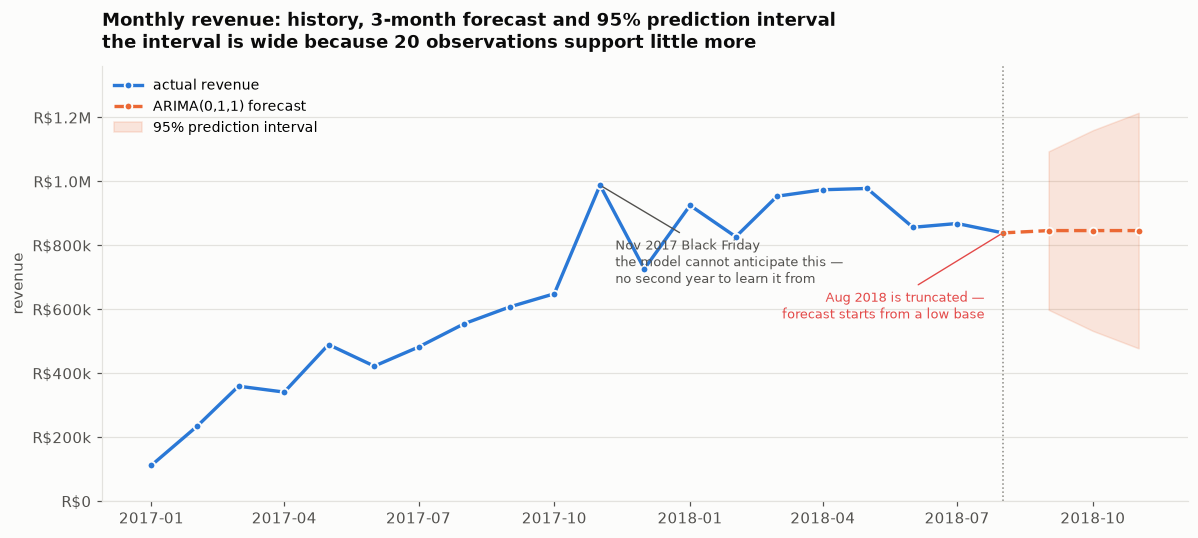

In [14]:
fig, ax = plt.subplots(figsize=(11, 5))

ax.plot(monthly.index, monthly.values, color=BLUE, linewidth=2.2, marker="o",
        markersize=5, markeredgecolor=SURFACE, markeredgewidth=1.2, label="actual revenue")

ax.plot([monthly.index[-1]] + list(fcast.index),
        [monthly.iloc[-1]] + list(fcast.forecast),
        color=ORANGE, linewidth=2.2, linestyle="--", marker="o", markersize=5,
        markeredgecolor=SURFACE, markeredgewidth=1.2, label="ARIMA(0,1,1) forecast")

ax.fill_between(fcast.index, fcast.lower, fcast.upper, color=ORANGE, alpha=0.16,
                label="95% prediction interval")

ax.axvline(monthly.index[-1], color=INK_3, linewidth=1, linestyle=":")
ax.annotate("Aug 2018 is truncated —\nforecast starts from a low base",
            xy=(monthly.index[-1], monthly.iloc[-1]), xytext=(-12, -56),
            textcoords="offset points", fontsize=8.5, color=NEG, ha="right",
            arrowprops=dict(arrowstyle="-", color=NEG, lw=0.9))

ax.annotate(f"Nov 2017 Black Friday\nthe model cannot anticipate this —\nno second year to learn it from",
            xy=(monthly.index[10], monthly.iloc[10]), xytext=(10, -64),
            textcoords="offset points", fontsize=8.5, color=INK_2,
            arrowprops=dict(arrowstyle="-", color=INK_2, lw=0.9))

ax.set_title("Monthly revenue: history, 3-month forecast and 95% prediction interval\n"
             "the interval is wide because 20 observations support little more")
ax.set_ylabel("revenue")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(brl))
ax.set_ylim(0, max(fcast.upper.max(), monthly.max()) * 1.12)
ax.legend(loc="upper left")
ax.grid(axis="x", visible=False); despine(ax)
plt.tight_layout(); plt.show()

In [15]:
width = (fcast.upper - fcast.lower)
rel = width / fcast.forecast * 100
summary = pd.DataFrame({
    "forecast": fcast.forecast,
    "lower_95": fcast.lower,
    "upper_95": fcast.upper,
    "interval_width": width,
    "width_as_pct_of_forecast": rel,
})
display(summary.round(2))
print(f"The 95% interval spans +/-{rel.iloc[0]/2:.0f}% of the point forecast in month 1,")
print(f"widening to +/-{rel.iloc[-1]/2:.0f}% by month {len(fcast)}.")
print("An interval this wide is the correct representation of what 20 monthly")
print("observations can support. A narrow interval here would be dishonest.")

,forecast,lower_95,upper_95,interval_width,width_as_pct_of_forecast
2018-09-01,"845,820.75","598,069.17","1,093,572.34","495,503.18",58.58
2018-10-01,"845,820.75","531,967.49","1,159,674.02","627,706.53",74.21
2018-11-01,"845,820.75","477,545.19","1,214,096.32","736,551.14",87.08


The 95% interval spans +/-29% of the point forecast in month 1,
widening to +/-44% by month 3.
An interval this wide is the correct representation of what 20 monthly
observations can support. A narrow interval here would be dishonest.


## 6. Save forecast output

In [16]:
history = pd.DataFrame({
    "period": monthly.index, "actual": monthly.values,
    "forecast": np.nan, "lower_95": np.nan, "upper_95": np.nan, "type": "actual",
})
future = pd.DataFrame({
    "period": fcast.index, "actual": np.nan, "forecast": fcast.forecast.values,
    "lower_95": fcast.lower.values, "upper_95": fcast.upper.values, "type": "forecast",
})
forecast_output = pd.concat([history, future], ignore_index=True)
forecast_output["period"] = pd.to_datetime(forecast_output.period)
forecast_output.to_parquet(PROC / "revenue_forecast.parquet", index=False)

results_m.reset_index().to_parquet(PROC / "forecast_model_comparison.parquet", index=False)

print(f"saved revenue_forecast.parquet ({len(forecast_output)} rows)")
print(f"saved forecast_model_comparison.parquet ({len(results_m)} rows)")
display(forecast_output.tail(6).round(2))

saved revenue_forecast.parquet (23 rows)
saved forecast_model_comparison.parquet (10 rows)


,period,actual,forecast,lower_95,upper_95,type
17,2018-06-01,"856,077.86",NaN,NaN,NaN,actual
18,2018-07-01,"867,953.46",NaN,NaN,NaN,actual
19,2018-08-01,"838,576.64",NaN,NaN,NaN,actual
20,2018-09-01,NaN,"845,820.75","598,069.17","1,093,572.34",forecast
21,2018-10-01,NaN,"845,820.75","531,967.49","1,159,674.02",forecast
22,2018-11-01,NaN,"845,820.75","477,545.19","1,214,096.32",forecast


## 7. Findings and limitations

### Findings

1. **The extract is truncated inside August 2018**, not just after it. Order counts fall from ~250
   to 11 per day over the final week. Monthly aggregation hid this completely.
2. **This corrected a headline finding.** On a like-for-like days 1–21 basis, August ran **+45.8%
   above July and within 1.5% of May** — July was the trough, not August. Notebook 03's "12%
   decline" claim was an artefact and has been updated.
3. **Monthly: a 3-month moving average wins** — MAE R$62,622, MAPE 7.13%, **31% better than naive**.
4. **Trend-extrapolating models fail badly** — Holt, Drift and the historical mean are 150–210%
   *worse* than naive, and Holt's fitted trend parameter collapsed to ~0. The series flattened after
   2017; models that project the old growth rate overshoot severely.
5. **Weekly seasonality is real at daily grain** — the differenced ACF spikes only at lags 7, 14, 21
   and 28, and weekday revenue varies ~49% between Monday and Saturday. Every seasonal model beats
   the naive baseline.
6. **Annual seasonality is not estimable** — 20 monthly points is fewer than two cycles, so **no
   SARIMA(m=12) was fitted**. The forecast structurally cannot anticipate another Black Friday.

### Limitations — stated plainly

1. **20 monthly observations.** Far below the ~50 usually wanted for ARIMA. The monthly ARIMA
   results should be treated as indicative, and the moving average — which won — is barely a model
   at all.
2. **Four test months.** Model ranking rests on four points; a different split could reorder the
   middle of the table. The clear separation between flat models and trend models is the robust
   part; the exact ordering is not.
3. **No annual seasonality, so no Black Friday.** November 2017 was 52% above October. The forecast
   cannot reproduce that, and any November projection from it will be far too low.
4. **No external regressors.** No marketing spend, pricing, promotions, competitor activity,
   macroeconomic or holiday-calendar inputs — none exist in this dataset. The forecast extrapolates
   the series' own history and nothing else.
5. **The forecast starts from an understated base.** August 2018 is truncated even after trimming
   the daily tail (the monthly point still includes thin days), so the point forecasts are
   conservative.
6. **Prediction intervals are wide** — roughly ±30% in month one, widening thereafter. That width
   is the honest output of a short, volatile series, not a modelling failure.
7. **The series ends in 2018.** This is a historical dataset; nothing here forecasts present-day
   conditions.

### What would improve this materially
Two to three more years of history (enabling annual seasonality and a real SARIMA), plus promotional
calendar and marketing spend as exogenous regressors. Both are additions to the data, not
improvements to the method.

---
**Next:** Phase 14 — Business Recommendations (`reports/business_recommendations.md`).